<a href="https://colab.research.google.com/github/chewanna7-code/NatureInsightStudy/blob/main/Wansbeck_Rainfall_Extractor_Cleaned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Wansbeck Rainfall Event Extraction and Antecedent Analysis

## Purpose

This notebook extracts rainfall conditions surrounding historic flood events within the River Wansbeck catchment.

The workflow was developed to support the hydrological assessment presented in the dissertation by providing a consistent method for examining rainfall conditions before, during and after major flood events.

---

## What This Notebook Does

- Uploads daily rainfall data.
- Extracts user-defined flood event windows.
- Calculates cumulative rainfall totals.
- Produces rainfall visualisations for each event.
- Generates summary tables for comparison between events.
- Exports figures and Excel outputs for further analysis.

---

## Why Was This Analysis Undertaken?

Flood response is influenced by both:

- Rainfall occurring on the flood day.
- Antecedent rainfall accumulated during previous days.

Understanding these conditions helps provide context when interpreting:

- Observed flood events.
- Hydrograph behaviour.
- Catchment wetness conditions.
- Differences between historic flood responses.

---

## Workflow

### Step 1 – Upload Rainfall Data
Import daily rainfall records.

### Step 2 – Define Flood Events
Specify event dates and analysis windows.

### Step 3 – Extract Event Rainfall
Filter records surrounding each flood event.

### Step 4 – Generate Figures
Create daily and cumulative rainfall plots.

### Step 5 – Export Results
Produce figures and Excel summaries for reporting.

---

## Dissertation Context

This notebook forms part of the hydrological assessment workflow used to investigate rainfall conditions associated with key flood events within the River Wansbeck catchment.


In [ ]:
# ============================================================
#  Imports

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from google.colab import files
import io
plt.rcParams['font.family'] = 'DejaVu Serif'
print('Ready.')

Ready.


---
## Step 1: Upload your rainfall file
Format expected: `DD/MM/YYYY` then rainfall in mm, tab or space separated.

In [ ]:
# ============================================================
#  Upload and parse rainfall file


print('Upload your rainfall CSV/TXT file...')
uploaded = files.upload()
fname = list(uploaded.keys())[0]
content = uploaded[fname].decode('utf-8', errors='ignore')

# Parse — handles tab, space, or comma separated
rows = []
for line in content.strip().split('\n'):
    line = line.strip()
    if not line: continue
    # Try splitting by tab, then multiple spaces, then comma
    for sep in ['\t', '  ', ',', ' ']:
        parts = [p.strip() for p in line.split(sep) if p.strip()]
        if len(parts) >= 2:
            try:
                date = pd.to_datetime(parts[0], dayfirst=True)
                rain = float(parts[1])
                rows.append({'date': date, 'rainfall_mm': rain})
                break
            except:
                continue

df_all = pd.DataFrame(rows).sort_values('date').reset_index(drop=True)
print(f'Loaded {len(df_all):,} records')
print(f'Date range: {df_all["date"].min().date()} to {df_all["date"].max().date()}')

# Filter to 2007-2008
df = df_all[(df_all['date'].dt.year >= 2007) & (df_all['date'].dt.year <= 2008)].copy()
print(f'2007-2008 records: {len(df):,}')
display(df.head())

Upload your rainfall CSV/TXT file...


Saving 22007_cdr.csv to 22007_cdr.csv


/tmp/ipykernel_7587/337012132.py:20: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  date = pd.to_datetime(parts[0], dayfirst=True)


Loaded 23,010 records
Date range: 1961-01-01 to 2023-12-31
2007-2008 records: 731


,date,rainfall_mm
16801,2007-01-01,0.8
16802,2007-01-02,0.0
16803,2007-01-03,0.0
16804,2007-01-04,0.1
16805,2007-01-05,0.0


---
## Step 2: Define your events
Edit the cell below — set peak date and window for each event.

In [ ]:
# ============================================================
# Define events


# Edit peak dates and window sizes here
events = [
    {
        'name'       : 'September 2008 Morpeth Flood',
        'peak_date'  : '09/06/2008',
        'days_before': 10,
        'days_after' : 6,
        'colour'     : '#c0392b',
        'ni_storm'   : 67.8,   # NI design storm mm for comparison
    },
    {
        'name'       : 'June 2007 Flood',
        'peak_date'  : '26/06/2007',
        'days_before': 10,
        'days_after' : 6,
        'colour'     : '#2980b9',
        'ni_storm'   : 67.8,
    },
]


print(f'Events defined: {len(events)}')
for e in events:
    print(f'  {e["name"]} | Peak: {e["peak_date"]}')

Events defined: 2
  September 2008 Morpeth Flood | Peak: 09/06/2008
  June 2007 Flood | Peak: 26/06/2007


---
## Step 3: Generate tables and figures


September 2008 Morpeth Flood:
  Pre-peak accumulation (10 days): 37.5 mm
  Peak day rainfall: 54.2 mm
  NI design storm: 67.8 mm
  Total window rainfall: 97.7 mm

Daily rainfall table:


,Date,Day,Daily Rainfall (mm),Cumulative (mm),Notes
0,30/05/2008,Friday,0.0,0.0,
1,31/05/2008,Saturday,0.2,0.2,
2,01/06/2008,Sunday,6.9,7.1,
3,02/06/2008,Monday,0.6,7.7,
4,03/06/2008,Tuesday,0.1,7.8,
5,04/06/2008,Wednesday,11.0,18.8,
6,05/06/2008,Thursday,0.0,18.8,
7,06/06/2008,Friday,0.6,19.4,
8,07/06/2008,Saturday,9.6,29.0,
9,08/06/2008,Sunday,8.5,37.5,


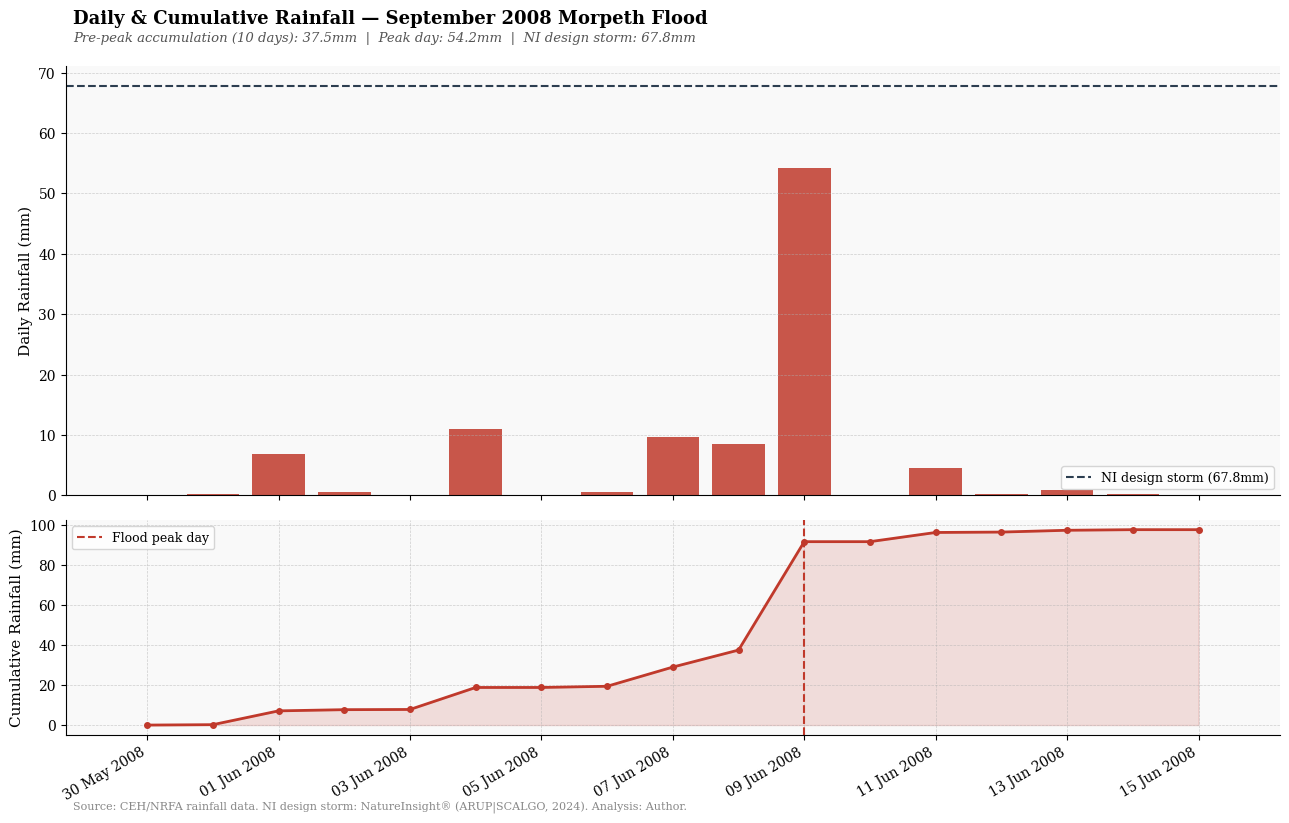


June 2007 Flood:
  Pre-peak accumulation (10 days): 57.7 mm
  Peak day rainfall: 2.0 mm
  NI design storm: 67.8 mm
  Total window rainfall: 100.8 mm

Daily rainfall table:


,Date,Day,Daily Rainfall (mm),Cumulative (mm),Notes
0,16/06/2007,Saturday,3.6,3.6,
1,17/06/2007,Sunday,0.9,4.5,
2,18/06/2007,Monday,0.1,4.6,
3,19/06/2007,Tuesday,19.9,24.5,
4,20/06/2007,Wednesday,0.0,24.5,
5,21/06/2007,Thursday,0.8,25.3,
6,22/06/2007,Friday,10.2,35.5,
7,23/06/2007,Saturday,10.3,45.8,
8,24/06/2007,Sunday,9.7,55.5,
9,25/06/2007,Monday,2.2,57.7,


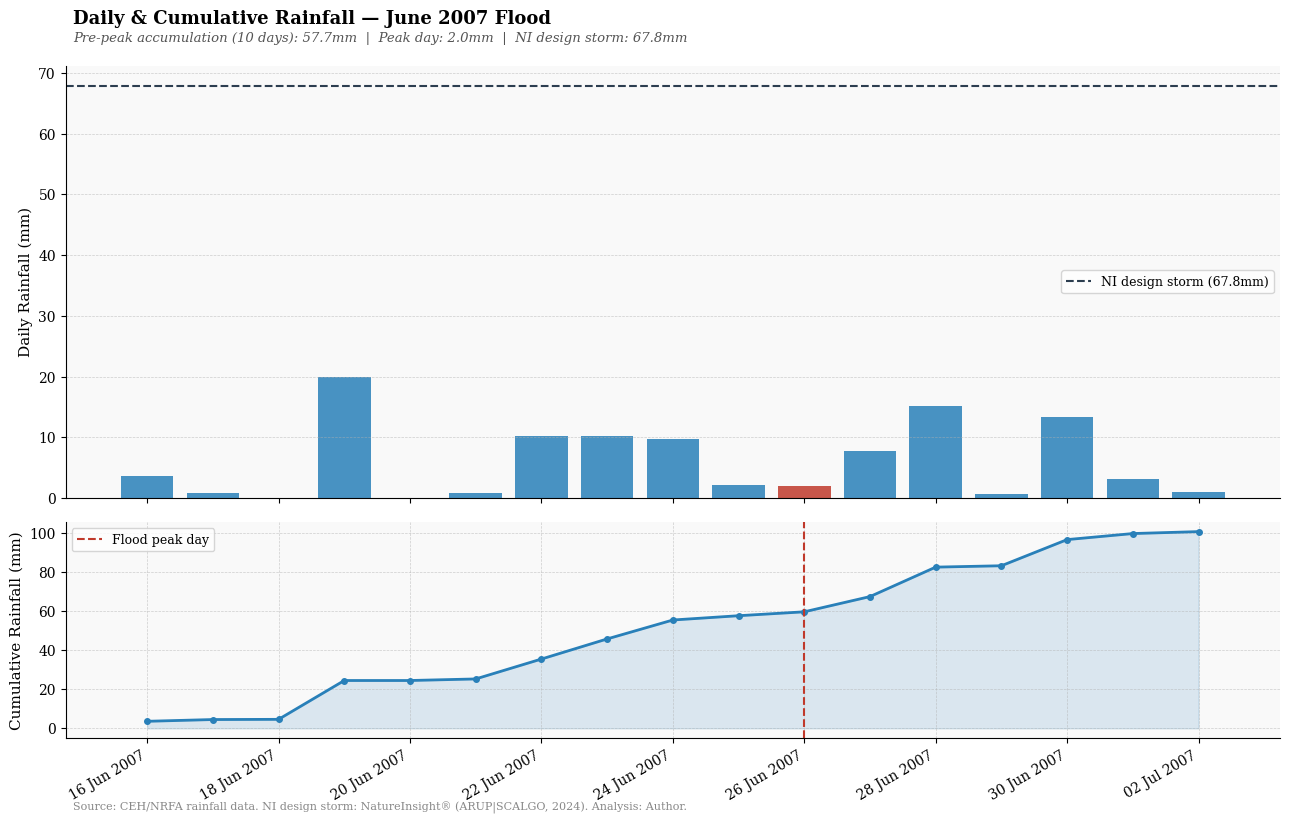


All events processed.


In [ ]:
# ============================================================
# Generate tables and figures


saved_figs   = []
all_summaries = []

for event in events:
    peak_dt   = pd.to_datetime(event['peak_date'], dayfirst=True)
    start_dt  = peak_dt - pd.Timedelta(days=event['days_before'])
    end_dt    = peak_dt + pd.Timedelta(days=event['days_after'])

    sub = df[(df['date'] >= start_dt) & (df['date'] <= end_dt)].copy()

    if sub.empty:
        print(f'WARNING: No data found for {event["name"]}')
        continue

    # Cumulative from start of window
    sub = sub.reset_index(drop=True)
    sub['cumulative_mm'] = sub['rainfall_mm'].cumsum().round(1)
    sub['day_of_week']   = sub['date'].dt.strftime('%A')
    sub['date_str']      = sub['date'].dt.strftime('%d/%m/%Y')
    sub['is_peak']       = sub['date'] == peak_dt
    sub['notes']         = sub.apply(
        lambda r: 'PEAK DAY' if r['is_peak']
        else ('Heavy rainfall' if r['rainfall_mm'] >= 20 else ''), axis=1)

    # Pre-peak accumulation
    pre_peak   = sub[sub['date'] < peak_dt]
    pre_total  = pre_peak['rainfall_mm'].sum()
    peak_rain  = sub.loc[sub['is_peak'], 'rainfall_mm'].values[0] if sub['is_peak'].any() else 0
    total_rain = sub['rainfall_mm'].sum()

    print(f'\n{event["name"]}:')
    print(f'  Pre-peak accumulation ({event["days_before"]} days): {pre_total:.1f} mm')
    print(f'  Peak day rainfall: {peak_rain:.1f} mm')
    print(f'  NI design storm: {event["ni_storm"]} mm')
    print(f'  Total window rainfall: {total_rain:.1f} mm')

    # ---- TABLE ----
    print(f'\nDaily rainfall table:')
    display(sub[['date_str','day_of_week','rainfall_mm','cumulative_mm','notes']].rename(columns={
        'date_str'    : 'Date',
        'day_of_week' : 'Day',
        'rainfall_mm' : 'Daily Rainfall (mm)',
        'cumulative_mm': 'Cumulative (mm)',
        'notes'       : 'Notes'
    }))

    # ---- FIGURE ----
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8),
                                    gridspec_kw={'height_ratios': [2, 1]},
                                    sharex=True)
    fig.patch.set_facecolor('white')

    # Bar chart — daily rainfall
    colours = [
        '#c0392b' if r['is_peak']
        else ('#e67e22' if r['rainfall_mm'] >= 20
              else event['colour'])
        for _, r in sub.iterrows()
    ]
    ax1.bar(sub['date'], sub['rainfall_mm'], color=colours, alpha=0.85, width=0.8)
    ax1.axhline(y=event['ni_storm'], color='#2c3e50', ls='--', lw=1.5,
                label=f'NI design storm ({event["ni_storm"]}mm)')
    ax1.set_ylabel('Daily Rainfall (mm)', fontsize=11)
    ax1.set_facecolor('#f9f9f9')
    ax1.grid(True, ls='--', lw=0.5, alpha=0.6, axis='y')
    ax1.legend(fontsize=9)
    for s in ['top','right']: ax1.spines[s].set_visible(False)

    # Cumulative line
    ax2.plot(sub['date'], sub['cumulative_mm'], '-o',
             color=event['colour'], linewidth=2, markersize=4)
    ax2.fill_between(sub['date'], sub['cumulative_mm'],
                     alpha=0.15, color=event['colour'])
    ax2.axvline(x=peak_dt, color='#c0392b', ls='--', lw=1.5,
                label='Flood peak day')
    ax2.set_ylabel('Cumulative Rainfall (mm)', fontsize=11)
    ax2.set_facecolor('#f9f9f9')
    ax2.grid(True, ls='--', lw=0.5, alpha=0.6)
    ax2.legend(fontsize=9)
    for s in ['top','right']: ax2.spines[s].set_visible(False)

    import matplotlib.dates as mdates
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
    ax2.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

    fig.suptitle(f'Daily & Cumulative Rainfall — {event["name"]}',
                 fontsize=13, fontweight='bold', x=0.06, ha='left', y=1.01)
    fig.text(0.06, 0.97,
             f'Pre-peak accumulation ({event["days_before"]} days): {pre_total:.1f}mm  |  '
             f'Peak day: {peak_rain:.1f}mm  |  NI design storm: {event["ni_storm"]}mm',
             fontsize=9.5, color='#555', style='italic')
    fig.text(0.06, 0.01,
             'Source: CEH/NRFA rainfall data. NI design storm: NatureInsight® (ARUP|SCALGO, 2024). Analysis: Author.',
             fontsize=8, color='#888')

    plt.tight_layout()
    fname_out = event['name'].replace(' ','_').replace('/','') + '_rainfall.png'
    plt.savefig(fname_out, dpi=300, bbox_inches='tight', facecolor='white')
    saved_figs.append(fname_out)
    plt.show()

    # Summary
    all_summaries.append({
        'Event'                          : event['name'],
        'Peak Date'                      : peak_dt.strftime('%d/%m/%Y'),
        f'Pre-peak Total ({event["days_before"]}d) mm' : round(pre_total, 1),
        'Peak Day Rainfall (mm)'         : round(peak_rain, 1),
        'NI Design Storm (mm)'           : event['ni_storm'],
        'Peak vs NI Storm'               : f'{((peak_rain/event["ni_storm"])-1)*100:+.1f}%',
        'Total Window Rainfall (mm)'     : round(total_rain, 1),
    })

print('\nAll events processed.')

In [ ]:
# ============================================================
# Summary comparison table + Excel export
# ============================================================

df_summary = pd.DataFrame(all_summaries)
print('\nSUMMARY COMPARISON TABLE:')
display(df_summary)

# Export to Excel
with pd.ExcelWriter('Wansbeck_Rainfall_Analysis.xlsx', engine='openpyxl') as writer:
    df_summary.to_excel(writer, sheet_name='Summary', index=False)
    for event in events:
        peak_dt  = pd.to_datetime(event['peak_date'], dayfirst=True)
        start_dt = peak_dt - pd.Timedelta(days=event['days_before'])
        end_dt   = peak_dt + pd.Timedelta(days=event['days_after'])
        sub = df[(df['date'] >= start_dt) & (df['date'] <= end_dt)].copy()
        if sub.empty: continue
        sub['cumulative_mm'] = sub['rainfall_mm'].cumsum().round(1)
        sub['day_of_week']   = sub['date'].dt.strftime('%A')
        sub['date_str']      = sub['date'].dt.strftime('%d/%m/%Y')
        sub[['date_str','day_of_week','rainfall_mm','cumulative_mm']].rename(
            columns={'date_str':'Date','day_of_week':'Day',
                     'rainfall_mm':'Daily Rainfall (mm)',
                     'cumulative_mm':'Cumulative (mm)'}
        ).to_excel(writer, sheet_name=event['name'][:31], index=False)

files.download('Wansbeck_Rainfall_Analysis.xlsx')
print('Excel saved.')


SUMMARY COMPARISON TABLE:


,Event,Peak Date,Pre-peak Total (10d) mm,Peak Day Rainfall (mm),NI Design Storm (mm),Peak vs NI Storm,Total Window Rainfall (mm)
0,September 2008 Morpeth Flood,06/09/2008,15.3,0.0,67.8,-100.0%,75.0
1,June 2007 Flood,26/06/2007,57.7,2.0,67.8,-97.1%,100.8


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Excel saved.


In [ ]:
# ============================================================
# Download figures
# ============================================================
for f in saved_figs:
    files.download(f)
    print(f'Downloaded: {f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: September_2008_Morpeth_Flood_rainfall.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: June_2007_Flood_rainfall.png
